In [1]:
# ============================================
# CHANGE THESE TWO LINES
# ============================================
GITHUB_USER = 'skm48'
REPO_NAME   = 'MINI_PROJECT'

import os

if not os.path.exists(f'/{REPO_NAME}'):
    # First time — clone
    !git clone https://github.com/Skm48/MINI_PROJECT.git
    print('Repo cloned!')
else:
    # Already cloned — pull latest
    !cd /content/{REPO_NAME} && git pull
    print('Pulled latest changes!')

os.chdir(f'/content/{REPO_NAME}')
print(f'Working directory: {os.getcwd()}')

Cloning into 'MINI_PROJECT'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 104 (delta 32), reused 81 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 11.64 MiB | 12.72 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Repo cloned!
Working directory: /content/MINI_PROJECT


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/MiniProject/archive.zip /content/MINI_PROJECT/data/
!unzip -q /content/MINI_PROJECT/data/archive.zip -d /content/MINI_PROJECT/data/

In [4]:
# Remove the Mac junk folder and nested duplicate
!rm -rf /content/MINI_PROJECT/data/chest_xray/__MACOSX
!rm -rf /content/MINI_PROJECT/data/chest_xray/chest_xray

# Check it's clean
!ls /content/MINI_PROJECT/data/chest_xray/

test  train  val


In [5]:
import torch
import importlib

# Force reload torchvision.models to ensure a fresh state
# This is an aggressive attempt to clear potential module corruption
import torchvision.models
importlib.reload(torchvision.models)

from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

# Load model properly
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Print architecture
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 97.2MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path

import torch
from torchvision import transforms

from src.utils import set_seed, get_device, load_config
from src.dataset import (
    collect_image_paths,
    stratified_split,
    get_transforms,
    get_dataloaders,
    compute_class_weights,
)

set_seed(42)
device = get_device()
config = load_config()

print('All imports ready')

Using GPU: Tesla T4
All imports ready


In [7]:
# Build everything in one call
loaders = get_dataloaders(config)

Total images found: 5856
  By original split: {'train': np.int64(5216), 'test': np.int64(624), 'val': np.int64(16)}
  By label: {1: np.int64(4273), 0: np.int64(1583)}

Merged train+val: 5232 images
Original test kept: 624 images

New split sizes:
  Train: 4650  (Normal: 1199, Pneumonia: 3451)
  Val:   582  (Normal: 150, Pneumonia: 432)
  Test:  624  (Normal: 234, Pneumonia: 390)

Split indices saved to: data/split_indices.csv

Class weights: Normal=1.939, Pneumonia=0.674

DataLoaders ready:
  Train: 146 batches (4650 images)
  Val:   19 batches (582 images)
  Test:  20 batches (624 images)


In [8]:
print("Original classifier:")
print(model.classifier)

# Replace classifier properly
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(256, 2)
)

Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [9]:
# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - trainable

print(f"Total params:     {total:,}")
print(f"Frozen params:    {frozen:,}")
print(f"Trainable params: {trainable:,}")

Total params:     4,335,998
Frozen params:    4,007,548
Trainable params: 328,450


In [10]:
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Get one batch
images, labels = next(iter(loaders['train']))

img = images[0].unsqueeze(0).to(device)
label = labels[0].item()

with torch.no_grad():
    output = model(img)

    # The model outputs 2 logits (for class 0 and class 1).
    # For binary classification with sigmoid thresholding, we typically consider
    # the logit for the positive class (Pneumonia, index 1).
    prob_pneumonia = torch.sigmoid(output[:, 1])  # Get probability for class 1
    pred = (prob_pneumonia > 0.5).int().item() # Threshold this single probability

label_names = {0: 'Normal', 1: 'Pneumonia'}

print(f"True label:  {label_names[label]}")
print(f"Prediction:  {label_names[pred]}")
print(f"Probability: {prob_pneumonia.item():.4f}") # Print the probability for Pneumonia
print(f"Raw output (logit): {output.squeeze().tolist()}") # Print both logits for context

True label:  Pneumonia
Prediction:  Normal
Probability: 0.4838
Raw output (logit): [-0.023948930203914642, -0.0648239329457283]


In [13]:
import torch.nn as nn
class_weights = loaders['class_weights'].to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimize trainable params (the classifier head)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Task
Implement a training function that takes the model, data loader, optimizer, and loss criterion as input. Inside this function, iterate through the training data, perform a forward pass, calculate the loss, compute gradients, and update the model's parameters. This function should return the average loss for the epoch.

## Implement Training Function

### Subtask:
Define a function for a single training epoch that iterates through the training DataLoader, performs forward and backward passes, calculates the loss, and updates model weights.


**Reasoning**:
I will define the `train_one_epoch` function as specified in the instructions to handle a single training epoch, including forward and backward passes, loss calculation, and weight updates.



In [14]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        _, predicted = torch.max(outputs.data, 1)
        correct_predictions += (predicted == labels).sum().item()

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

print("train_one_epoch function defined.")

train_one_epoch function defined.


**Reasoning**:
I will define the `validate_one_epoch` function as specified, which includes setting the model to evaluation mode, iterating through the validation dataloader, performing a forward pass, calculating the loss, and returning the average loss without computing gradients.



In [15]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

print("validate_one_epoch function defined.")

validate_one_epoch function defined.


**Reasoning**:
I will implement the main training loop as described in the instructions, which includes initializing variables, running training and validation epochs, applying the LR scheduler, and implementing early stopping and model saving.



In [16]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
early_stopping_counter = 0

num_epochs_frozen = config['training']['epochs_frozen']
patience = config['training']['early_stopping_patience']

print(f"\nStarting training for {num_epochs_frozen} epochs (frozen layers).")

for epoch in range(num_epochs_frozen):

    train_loss, train_acc = train_one_epoch(model, loaders['train'], optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, loaders['val'], criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs_frozen} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)

    # ✅ Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0

        torch.save(model.state_dict(), 'best_model_frozen.pth')
        print("\tNew best model saved!")

    else:
        early_stopping_counter += 1
        print(f"\tEarly stopping counter: {early_stopping_counter}/{patience}")

        if early_stopping_counter >= patience:
            print(f"\tEarly stopping triggered after {patience} epochs without improvement.")
            break

print("Training complete for frozen layers. Loading best model...")

try:
    model.load_state_dict(torch.load('best_model_frozen.pth'))
    print("Best model loaded successfully.")
except FileNotFoundError:
    print("No best model found.")


Starting training for 10 epochs (frozen layers).
Epoch 1/10 | Train Loss: 0.2639 | Train Acc: 0.8978 | Val Loss: 0.1639 | Val Acc: 0.9278
	New best model saved!
Epoch 2/10 | Train Loss: 0.1926 | Train Acc: 0.9230 | Val Loss: 0.2130 | Val Acc: 0.8797
	Early stopping counter: 1/5
Epoch 3/10 | Train Loss: 0.1983 | Train Acc: 0.9194 | Val Loss: 0.1531 | Val Acc: 0.9227
	New best model saved!
Epoch 4/10 | Train Loss: 0.1738 | Train Acc: 0.9303 | Val Loss: 0.1692 | Val Acc: 0.9038
	Early stopping counter: 1/5
Epoch 5/10 | Train Loss: 0.1684 | Train Acc: 0.9344 | Val Loss: 0.1534 | Val Acc: 0.9192
	Early stopping counter: 2/5
Epoch 6/10 | Train Loss: 0.1660 | Train Acc: 0.9346 | Val Loss: 0.1300 | Val Acc: 0.9296
	New best model saved!
Epoch 7/10 | Train Loss: 0.1497 | Train Acc: 0.9396 | Val Loss: 0.1230 | Val Acc: 0.9330
	New best model saved!
Epoch 8/10 | Train Loss: 0.1513 | Train Acc: 0.9404 | Val Loss: 0.1263 | Val Acc: 0.9330
	Early stopping counter: 1/5
Epoch 9/10 | Train Loss: 0.162

## Implement Validation Function

### Subtask:
Define a function for a single validation epoch that iterates through the validation DataLoader, performs a forward pass, calculates the loss, and computes relevant metrics without updating weights.


## Run Main Training Loop

### Subtask:
Implement the main training loop, which orchestrates the training and validation epochs, tracks metrics, applies the learning rate scheduler, and incorporates early stopping based on validation performance.


# Task
Fix the `NameError` by adding `from src.utils import load_config` and `config = load_config()` at the beginning of cell `ccab7578`, then run the modified cell to execute the main training loop with frozen layers, including training and validation epochs, LR scheduling, and early stopping.

## Fix NameError for config

### Subtask:
Add the import for `load_config` and define the `config` variable at the beginning of cell `ccab7578` to resolve the `NameError`.


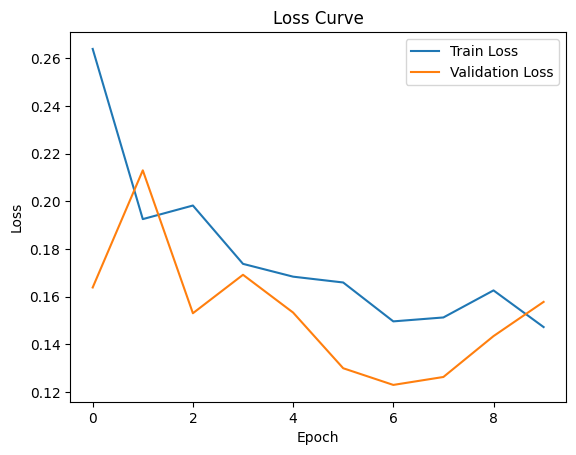

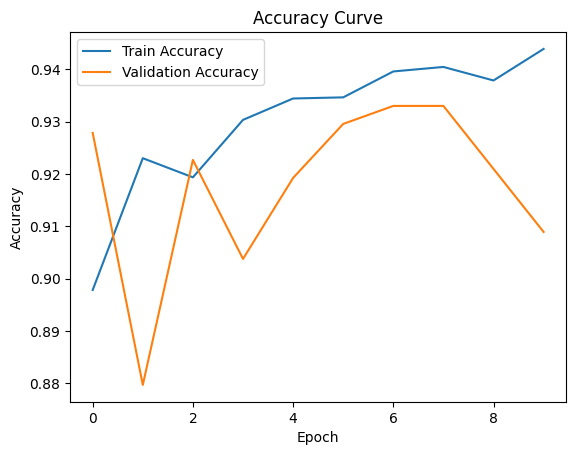

In [18]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy (if tracked)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [28]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loaders['val']:
        images = images.to(device)
        labels = labels.to(device) # Labels should be LongTensor, not float, and no unsqueeze(1) is needed here

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Get the predicted class (0 or 1) from the logits

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # For confusion matrix, append the predicted class (integer) and actual label (integer)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9330


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Convert all_labels to a 1D array of integers
all_labels_flat = np.array(all_labels).flatten().astype(int)

# Convert all_preds to a 1D array of predicted class integers
# Assuming all_preds are in a binary indicator format (e.g., [1., 0.] for class 0, [0., 1.] for class 1)
all_preds_flat = np.argmax(np.array(all_preds), axis=1).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(all_labels_flat, all_preds_flat))

print("\nClassification Report:")
print(classification_report(all_labels_flat, all_preds_flat))

Confusion Matrix:
[[147   3]
 [ 41 391]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87       150
           1       0.99      0.91      0.95       432

    accuracy                           0.92       582
   macro avg       0.89      0.94      0.91       582
weighted avg       0.94      0.92      0.93       582



In [25]:
# Unfreeze feature extractor
for param in model.features.parameters():
    param.requires_grad = True

# Lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Starting fine-tuning...")

Starting fine-tuning...


In [27]:
import os

# Define the path for the checkpoint directory
checkpoint_dir = "model/checkpoints"

# Create the directory if it doesn't exist
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(checkpoint_dir, "final_model.pth"))
print("Final model saved.")

Final model saved.


In [30]:
# Load best Phase 1 weights
model.load_state_dict(torch.load('best_model_frozen.pth'))

# Unfreeze last blocks
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {trainable:,}")

# New optimizer with lower learning rate
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,          # slightly higher than 1e-6 (more stable for EfficientNet)
    weight_decay=1e-4,
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

Trainable params after unfreeze: 4,335,998


In [33]:
from tqdm.notebook import tqdm

num_epochs = 10
best_val_loss = float('inf')

train_losses2, val_losses2 = [], []
train_accs2, val_accs2 = [], []

for epoch in range(num_epochs):

    # ---- TRAIN ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loaders['train'], desc=f"Epoch {epoch+1}/{num_epochs}"):

        images = images.to(device)
        # Correct labels for CrossEntropyLoss: should be LongTensor of shape (N)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # For accuracy with CrossEntropyLoss, take argmax of outputs
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    train_losses2.append(train_loss)
    train_accs2.append(train_acc)

    # ---- VALIDATE ----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loaders['val']:

            images = images.to(device)
            # Correct labels for CrossEntropyLoss: should be LongTensor of shape (N)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # For accuracy with CrossEntropyLoss, take argmax of outputs
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    val_losses2.append(val_loss)
    val_accs2.append(val_acc)

    scheduler.step(val_loss)

    # ---- CHECKPOINT ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'model/checkpoints/efficientnet_b0_best.pth')

    print(f"Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print("\nPhase 2 complete! Best val loss:", f"{best_val_loss:.4f}")

Epoch 1/10:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1299 train_acc=0.9488 | val_loss=0.1163 val_acc=0.9381


Epoch 2/10:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 2: train_loss=0.1260 train_acc=0.9477 | val_loss=0.1014 val_acc=0.9502


Epoch 3/10:   0%|          | 0/146 [00:00<?, ?it/s]

...

Epoch 8: train_loss=0.0877 train_acc=0.9652 | val_loss=0.0788 val_acc=0.9553


Epoch 9/10:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 9: train_loss=0.0719 train_acc=0.9718 | val_loss=0.0702 val_acc=0.9553


Epoch 10/10:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 10: train_loss=0.0656 train_acc=0.9731 | val_loss=0.0693 val_acc=0.9605

Phase 2 complete! Best val loss: 0.0693


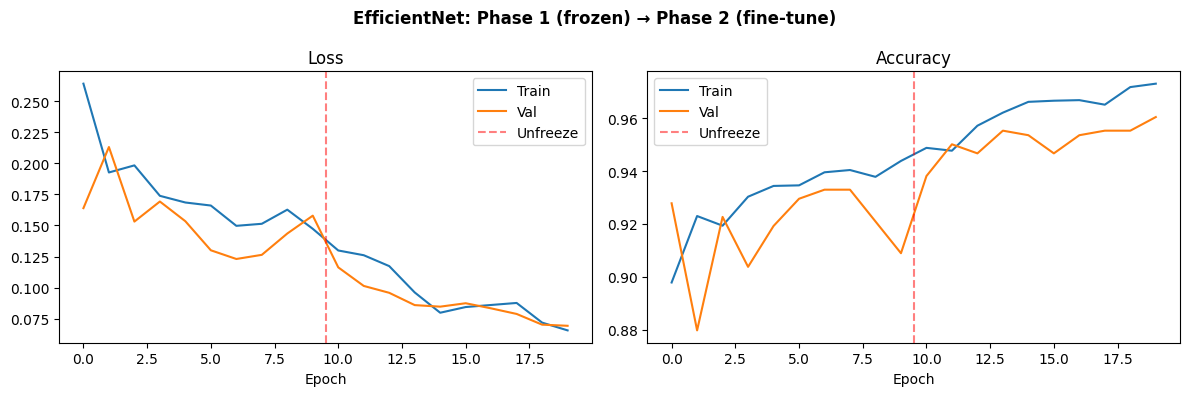

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_train_loss = history['train_loss'] + train_losses2
all_val_loss = history['val_loss'] + val_losses2
all_train_acc = history['train_acc'] + train_accs2
all_val_acc = history['val_acc'] + val_accs2

axes[0].plot(all_train_loss, label='Train')
axes[0].plot(all_val_loss, label='Val')
axes[0].axvline(x=len(history['train_loss'])-0.5, color='red', linestyle='--', alpha=0.5, label='Unfreeze')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(all_train_acc, label='Train')
axes[1].plot(all_val_acc, label='Val')
axes[1].axvline(x=len(history['train_acc'])-0.5, color='red', linestyle='--', alpha=0.5, label='Unfreeze')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('EfficientNet: Phase 1 (frozen) → Phase 2 (fine-tune)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/efficientnet_full_curves.png', dpi=150, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

      Normal       0.94      0.74      0.82       234
   Pneumonia       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

Accuracy:  0.8830
F1 Score:  0.8794
AUC-ROC:   0.9573


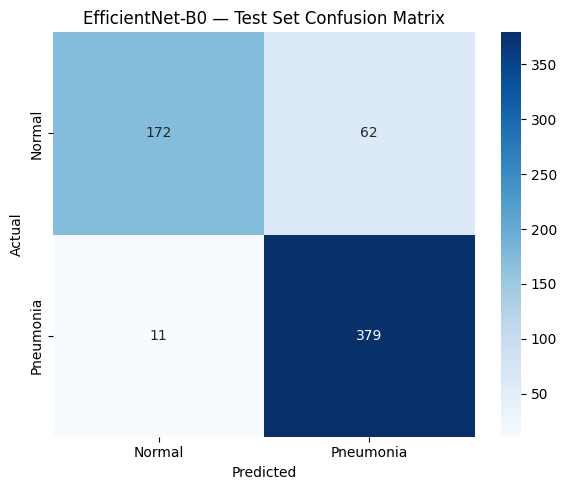


True Negatives (Normal correctly):   172
False Positives (Normal → Pneumonia): 62
False Negatives (Pneumonia → Normal): 11
True Positives (Pneumonia correctly): 379


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Load best Phase 2 weights
model.load_state_dict(torch.load('model/checkpoints/efficientnet_b0_best.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in loaders['test']:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # outputs are logits of shape (batch_size, 2)

        # For AUC, get probabilities using softmax on logits
        # and take the probability of the positive class (Pneumonia, index 1)
        probs = torch.softmax(outputs, dim=1)[:, 1] # probs will be (batch_size,)

        # For classification report and confusion matrix, get predicted class labels
        # by taking the argmax of the logits (consistent with CrossEntropyLoss training)
        _, preds = torch.max(outputs, 1) # preds will be (batch_size,)

        all_preds.extend(preds.cpu().numpy()) # Already 1D array of class indices
        all_labels.extend(labels.cpu().numpy()) # Already 1D array of class indices
        all_probs.extend(probs.cpu().numpy()) # Already 1D array of probabilities

# Classification report
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

# Key metrics
accuracy = sum(1 for a, b in zip(all_labels, all_preds) if a == b) / len(all_labels)
f1 = f1_score(all_labels, all_preds, average='weighted')
auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia'],
    ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('EfficientNet-B0 — Test Set Confusion Matrix')

plt.tight_layout()
plt.savefig('outputs/figures/efficientnet_b0_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives (Normal correctly):   {tn}")
print(f"False Positives (Normal → Pneumonia): {fp}")
print(f"False Negatives (Pneumonia → Normal): {fn}")
print(f"True Positives (Pneumonia correctly): {tp}")

In [38]:

!cd /content/MINI_PROJECT && git config user.name "Skm48"
!cd /content/MINI_PROJECT && git config user.email "skm48@student.le.ac.uk"

In [39]:
!cd /content/MINI_PROJECT && git remote set-url origin https://Skm48@github.com/Skm48/MINI_PROJECT.git


In [41]:
!cp /content/drive/My\ Drive/Colab\ Notebooks/EfficientNet-B0.ipynb /content/MINI_PROJECT/notebooks/


cp: cannot stat '/content/drive/My Drive/Colab Notebooks/EfficientNet-B0.ipynb': No such file or directory
